<a href="https://colab.research.google.com/github/SemniCode/Machine-Learning/blob/Project/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://github.com/terri1102/Stock_price_prediction/blob/main/stock_price_prediction.ipynb

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
#plt.rc('font', family='NanumSquareRound')
import matplotlib.pyplot as plt

plt.rc('font', family='NanumSquareRound')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,166 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123623 files and dire

In [ ]:
import pandas_datareader.data as web
from datetime import datetime
import yfinance as yf

snp500 = yf.download('^GSPC', start='2014-11-01', end='2024-11-01', progress=False, auto_adjust=True)
snp500 = pd.DataFrame(snp500)
snp500

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2014-11-03 00:00:00+00:00,2017.810059,2024.459961,2013.680054,2018.209961,3555440000
2014-11-04 00:00:00+00:00,2012.099976,2015.979980,2001.010010,2015.810059,3956260000
2014-11-05 00:00:00+00:00,2023.569946,2023.770020,2014.420044,2015.290039,3766590000
2014-11-06 00:00:00+00:00,2031.209961,2031.609985,2015.859985,2023.329956,3669770000
2014-11-07 00:00:00+00:00,2031.920044,2034.260010,2025.069946,2032.359985,3704280000
...,...,...,...,...,...
2024-10-25 00:00:00+00:00,5808.120117,5862.819824,5799.979980,5826.750000,3501280000
2024-10-28 00:00:00+00:00,5823.520020,5842.919922,5823.080078,5833.930176,3691280000


In [ ]:
!pip install --upgrade mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
snp500daily = snp500[['Open','High','Low','Close','Volume']].iloc[-250:]
snp500daily = snp500daily.astype('float')

In [ ]:
print(snp500daily.isna().sum())  # Check for missing values

Price   Ticker
Open    ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Close   ^GSPC     0
Volume  ^GSPC     0
dtype: int64


In [ ]:
# Option 1: Fill NaNs with the last valid value
snp500daily.fillna(method='ffill', inplace=True)

# Option 2: Drop rows with NaNs
snp500daily.dropna(inplace=True)

In [ ]:
print(type(snp500daily))          # Should print <class 'pandas.core.frame.DataFrame'>
print(type(snp500daily['Open']))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
snp500daily.columns = snp500daily.columns.get_level_values(0)

In [ ]:
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    snp500daily[col] = pd.to_numeric(snp500daily[col], errors='coerce')

In [ ]:
print(type(snp500daily))
print(type(snp500daily['Open']))  # Should now be a Series

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [ ]:
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    snp500daily[col] = pd.to_numeric(snp500daily[col], errors='coerce')

In [ ]:
snp500daily.fillna(method='ffill', inplace=True)  # Forward fill any NaNs
snp500daily.fillna(method='bfill', inplace=True)  # Backward fill as a backup

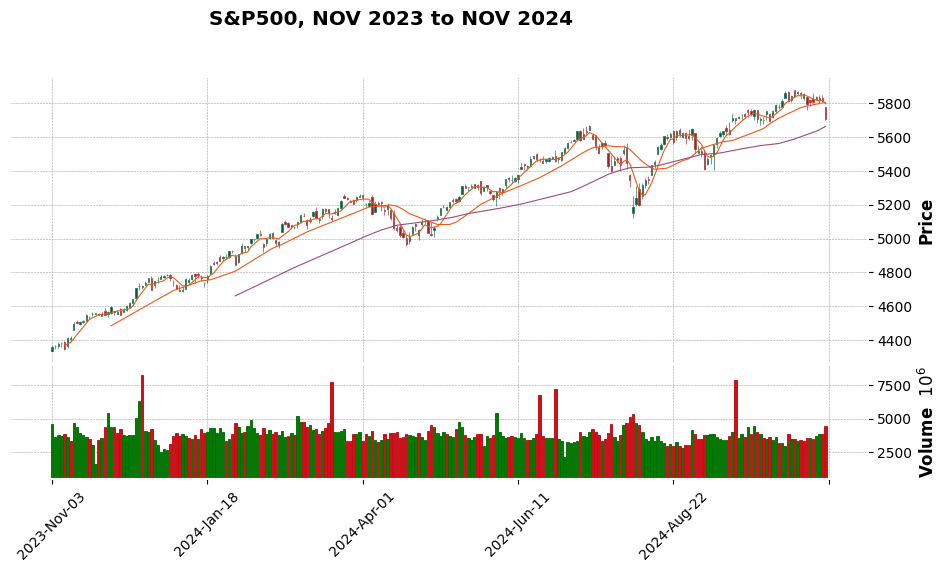

In [ ]:
import mplfinance as mpf
mpf.plot(snp500daily, type='candle', mav=(5, 20, 60),
         style='charles',
         title='S&P500, NOV 2023 to NOV 2024',
         figratio=(29, 14), volume=True)

In [ ]:
spy = yf.download('SPY', start='2014-11-01', end='2024-11-01', progress=False)
spy

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2014-11-03 00:00:00+00:00,169.154785,201.770004,202.449997,201.309998,201.919998,93600000
2014-11-04 00:00:00+00:00,168.567993,201.070007,201.600006,200.059998,201.229996,93343000
2014-11-05 00:00:00+00:00,169.632690,202.339996,202.589996,201.449997,202.539993,91709000
2014-11-06 00:00:00+00:00,170.311829,203.149994,203.259995,201.639999,202.389999,107089000
2014-11-07 00:00:00+00:00,170.471085,203.339996,203.600006,202.610001,203.169998,89540000
...,...,...,...,...,...,...
2024-10-25 00:00:00+00:00,579.039978,579.039978,584.460022,578.080017,581.510010,47268200
2024-10-28 00:00:00+00:00,580.830017,580.830017,582.710022,580.520020,582.580017,30174700


In [ ]:
# 결측치 확인
spy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2014-11-03 00:00:00+00:00 to 2024-10-31 00:00:00+00:00
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, SPY)  2516 non-null   float64
 1   (Close, SPY)      2516 non-null   float64
 2   (High, SPY)       2516 non-null   float64
 3   (Low, SPY)        2516 non-null   float64
 4   (Open, SPY)       2516 non-null   float64
 5   (Volume, SPY)     2516 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.6 KB


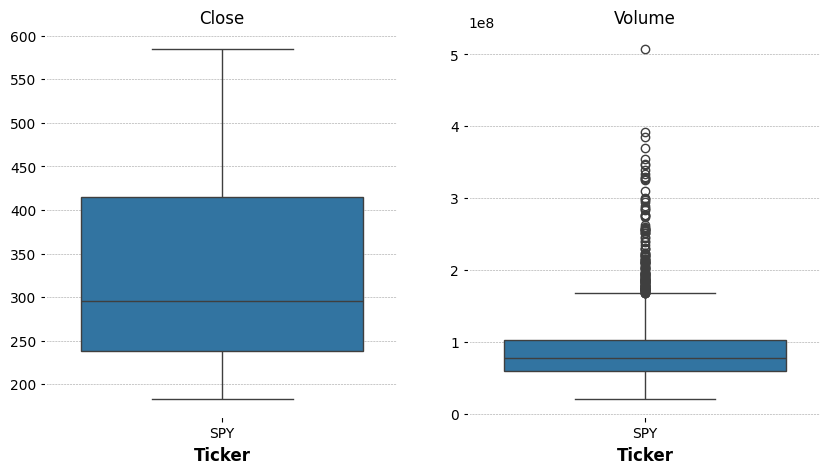

In [ ]:
# 이상치 확인
spy = spy.astype('float')
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1, 2, 1)
ax1 = sns.boxplot(spy['Close']);
ax1.set_title('Close')

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title('Volume')
#ax1.plot(x, y)
#ax2.bar(x, y)

ax2=sns.boxplot(spy['Volume']);

plt.show()

In [ ]:
spydaily = spy[-250:]
spydaily = spydaily.astype('float')


In [ ]:
spydaily.columns = spydaily.columns.get_level_values(0)

In [ ]:
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    spydaily[col] = pd.to_numeric(spydaily[col], errors='coerce')

In [ ]:
spydaily.fillna(method='ffill', inplace=True)  # Forward fill any NaNs
spydaily.fillna(method='bfill', inplace=True)  # Backward fill as a backup

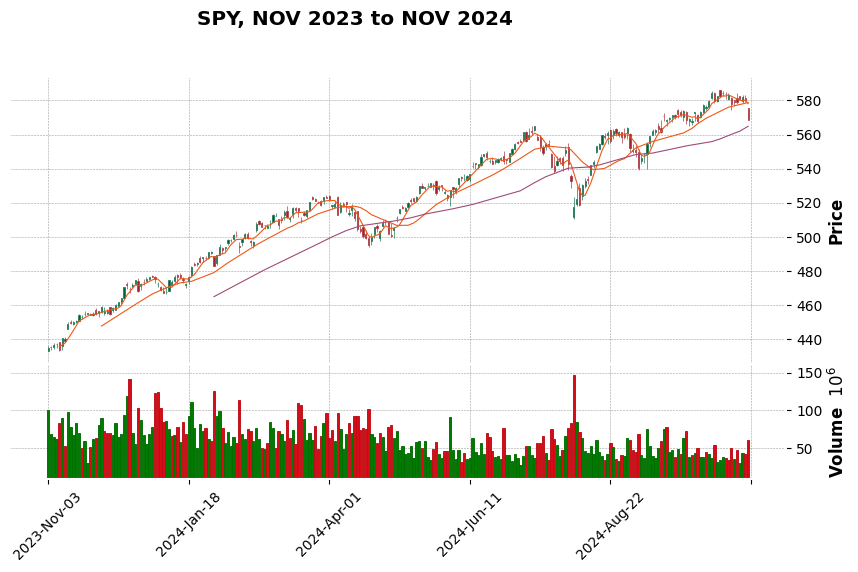

In [ ]:
mpf.plot(spydaily,type='candle',mav=(5,20, 60),
         style='charles',
         title='SPY, NOV 2023 to NOV 2024',
         figratio=(15,8),volume=True)

<Axes: xlabel='Date'>

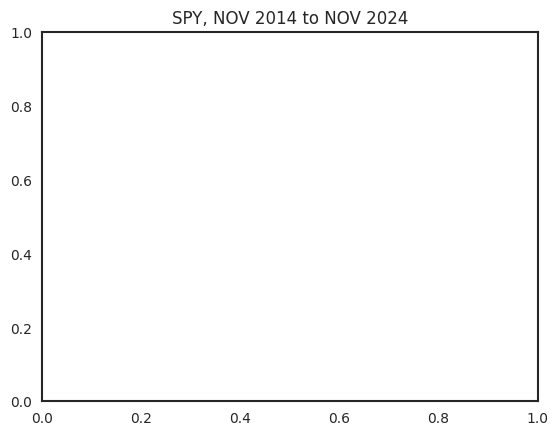

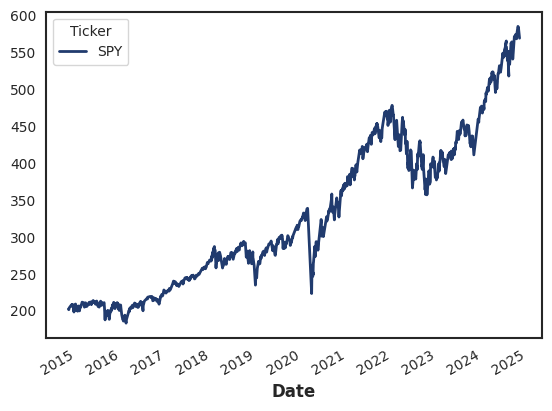

In [ ]:
# SPY 10년치 추세
sns.set_style('white')
sns.set_palette('cividis')
spy = spy.astype('float')
plt.title("SPY, NOV 2014 to NOV 2024")
spy['Close'].plot()

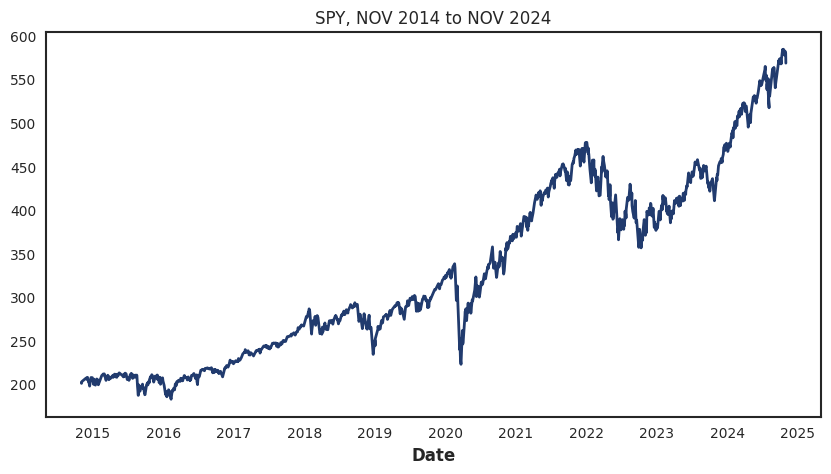

In [ ]:
sns.set_style('white')
sns.set_palette('cividis')
spy = spy.astype('float')
# Create a figure and axis, and plot on this specific axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(spy['Close'])
ax.set_title("SPY, NOV 2014 to NOV 2024")
ax.set_xlabel("Date")  # Set the x-axis label

# Display the plot
plt.show()

In [ ]:
#@title 시계열 데이터 전처리
# 정상성(Stationarity) 확인

from statsmodels.tsa.stattools import kpss
print(kpss(spy['Close'], regression='ct') )

(0.5062227687523552, 0.01, 30, {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})


<ipython-input-25-4c8b536ff679>:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print(kpss(spy['Close'], regression='ct') )


In [ ]:
# 차분 구하기
spy = spy.astype('float')
# spy['Diff'] =  np.r_[0, np.diff(spy['Close'])]
# Calculate the difference and assign it to a new column
spy['Diff'] = spy['Close'].diff().fillna(0)

spy

Price,Adj Close,Close,High,Low,Open,Volume,Diff
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,,
2014-11-03 00:00:00+00:00,169.154785,201.770004,202.449997,201.309998,201.919998,93600000.0,0.000000
2014-11-04 00:00:00+00:00,168.567993,201.070007,201.600006,200.059998,201.229996,93343000.0,-0.699997
2014-11-05 00:00:00+00:00,169.632690,202.339996,202.589996,201.449997,202.539993,91709000.0,1.269989
2014-11-06 00:00:00+00:00,170.311829,203.149994,203.259995,201.639999,202.389999,107089000.0,0.809998
2014-11-07 00:00:00+00:00,170.471085,203.339996,203.600006,202.610001,203.169998,89540000.0,0.190002
...,...,...,...,...,...,...,...
2024-10-25 00:00:00+00:00,579.039978,579.039978,584.460022,578.080017,581.510010,47268200.0,-0.200012
2024-10-28 00:00:00+00:00,580.830017,580.830017,582.710022,580.520020,582.580017,30174700.0,1.790039


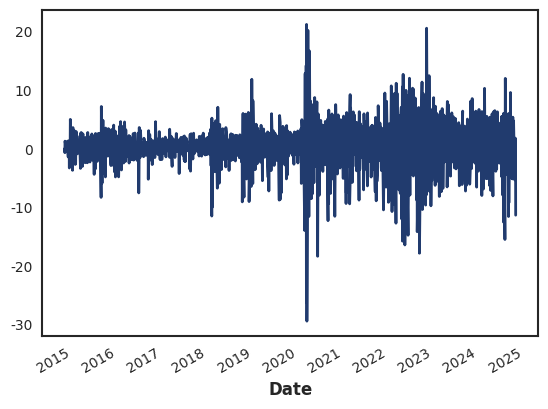

In [ ]:
import seaborn as sns
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_palette('cividis')
spy['Diff'].plot();

t기간의 SPY 종가에서 t-1기간의 SPY 종가를 뺀 차분을 구한 후 이를 그래프로 나타낸 것입니다. SPY지수 종가와는 다르게 일정한 분산을 보이는 것을 알 수 있습니다.

In [ ]:
from statsmodels.tsa.stattools import kpss
print(kpss(spy['Diff'], regression='ct') )

(0.032913345362765106, 0.1, 4, {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})


<ipython-input-28-ee3a74f4040c>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(kpss(spy['Diff'], regression='ct') )


In [ ]:
# prompt: from statsmodels.tsa.stattools import kpss
# print(kpss(spy['Diff'], regression='ct') )
# create a table with that

kpss_result = kpss(spy['Diff'], regression='ct')

# Create a table from the KPSS result
kpss_table = pd.DataFrame({
    'Statistic': [kpss_result[0]],
    'p-value': [kpss_result[1]],
    'lags': [kpss_result[2]],
    'Critical Values': [kpss_result[3]]
})

kpss_table

<ipython-input-29-82fbc9c5f138>:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(spy['Diff'], regression='ct')


,Statistic,p-value,lags,Critical Values
0,0.032913,0.1,4,"{'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%..."


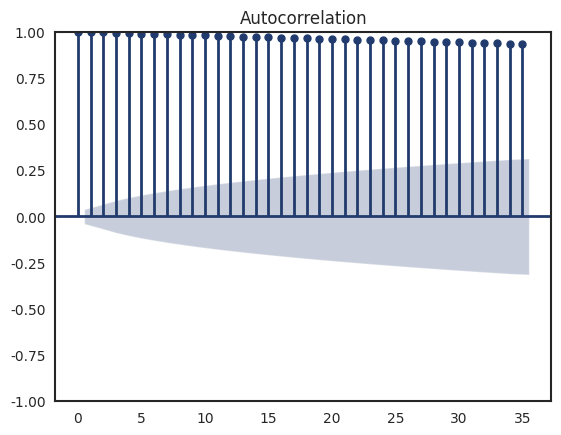

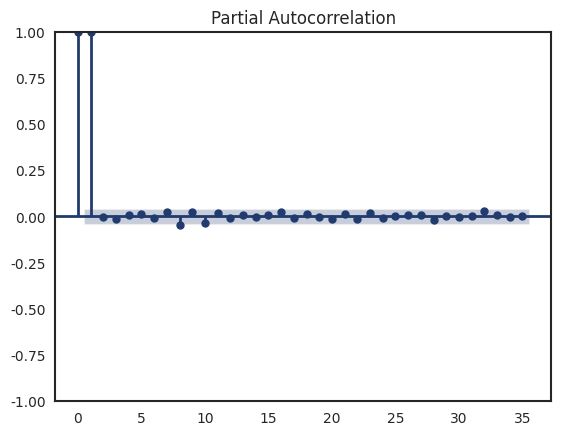

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(spy['Close'])
plot_pacf(spy['Close'])
plt.show()

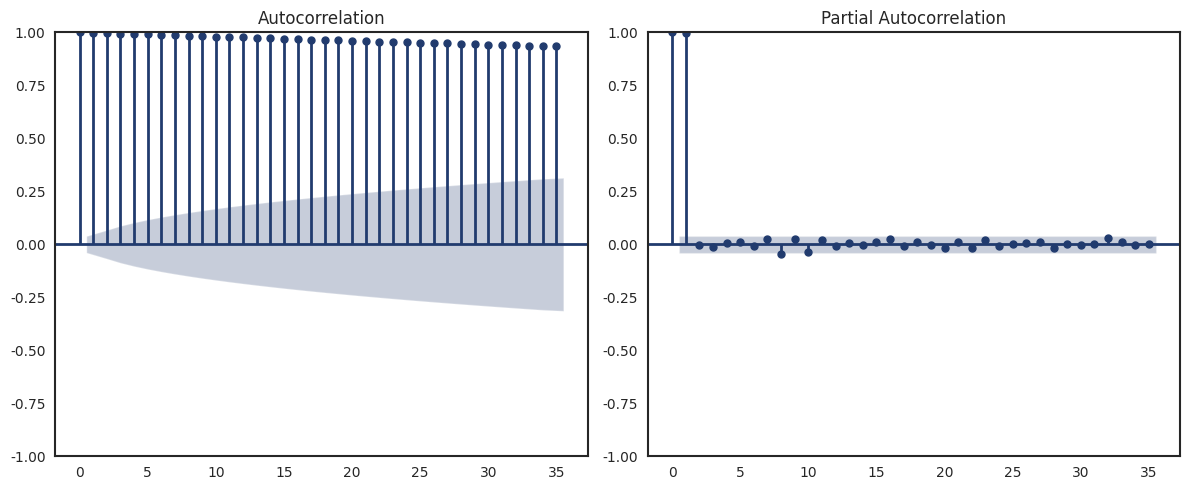

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot autocorrelation
plot_acf(spy['Close'], ax=axes[0], title="Autocorrelation")

# Plot partial autocorrelation
plot_pacf(spy['Close'], ax=axes[1], title="Partial Autocorrelation")

# Show the plot
plt.tight_layout()
plt.show()

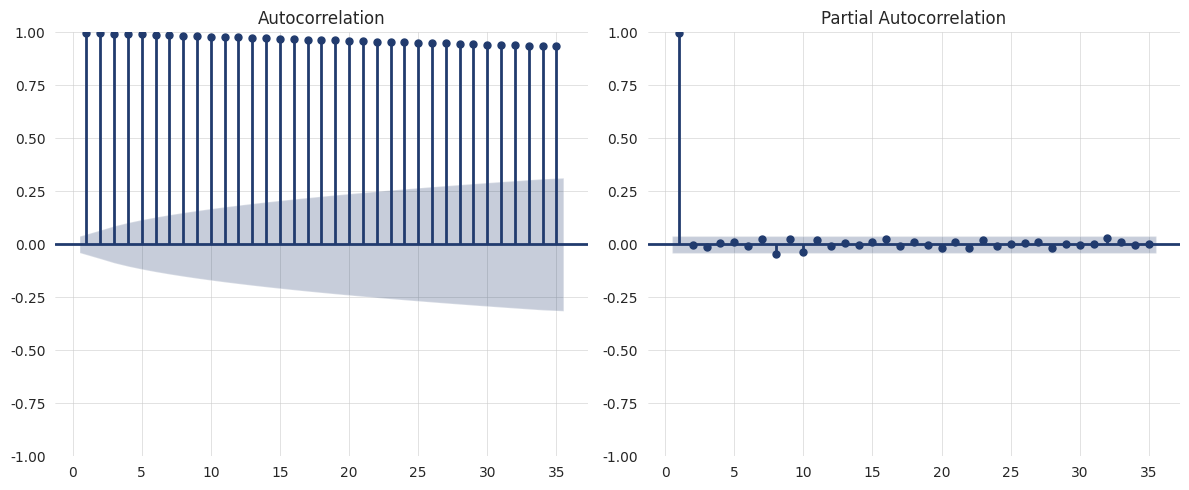

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Set Seaborn style to match your desired aesthetic
sns.set_style("whitegrid")

# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot autocorrelation without box line
plot_acf(spy['Close'], ax=axes[0], title="Autocorrelation", zero=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Plot partial autocorrelation without box line
plot_pacf(spy['Close'], ax=axes[1], title="Partial Autocorrelation", zero=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

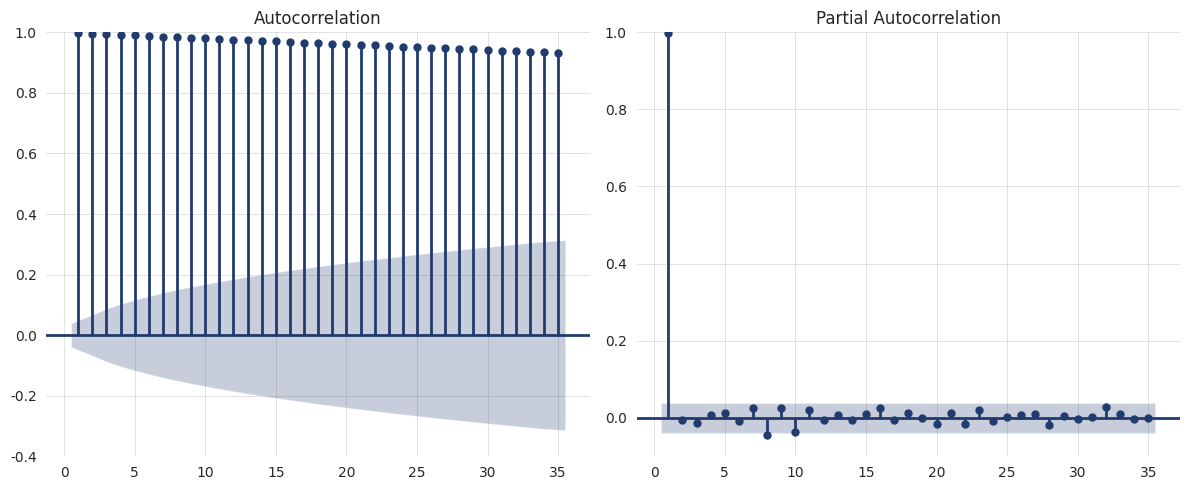

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Set Seaborn style to match your desired aesthetic
sns.set_style("whitegrid")

# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot autocorrelation without box line and set y-limit
plot_acf(spy['Close'], ax=axes[0], title="Autocorrelation", zero=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].set_ylim(-0.4, 1)  # Set the y-axis limit to cut off part of the lower area

# Plot partial autocorrelation without box line and set y-limit
plot_pacf(spy['Close'], ax=axes[1], title="Partial Autocorrelation", zero=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].set_ylim(-0.1, 1)  # Set the y-axis limit to cut off part of the lower area

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


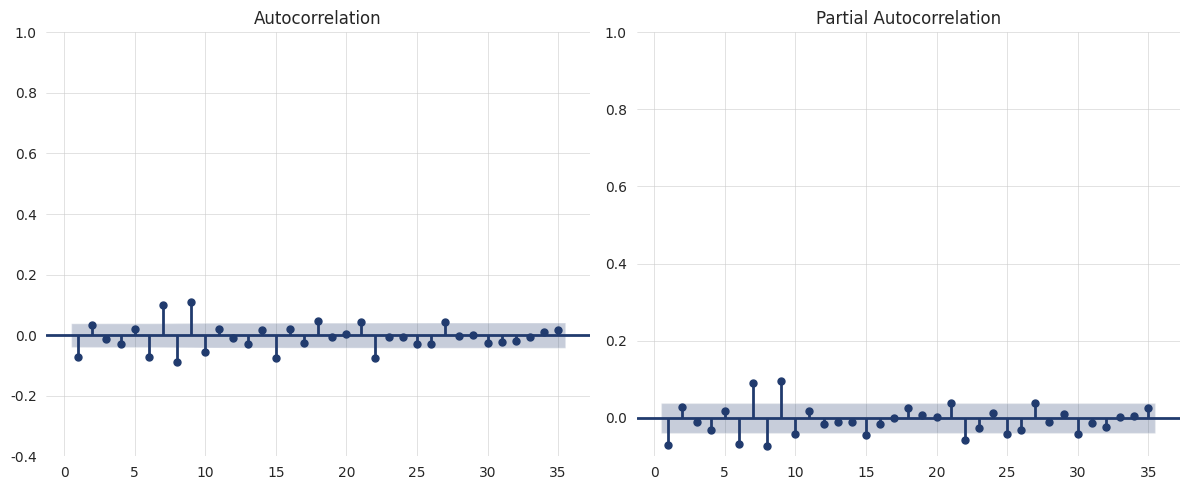

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Set Seaborn style to match your desired aesthetic
sns.set_style("whitegrid")

# Create a figure with two subplots in one row
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot autocorrelation without box line and set y-limit
plot_acf(spy['Diff'], ax=axes[0], title="Autocorrelation", zero=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].set_ylim(-0.4, 1)  # Set the y-axis limit to cut off part of the lower area

# Plot partial autocorrelation without box line and set y-limit
plot_pacf(spy['Diff'], ax=axes[1], title="Partial Autocorrelation", zero=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].set_ylim(-0.1, 1)  # Set the y-axis limit to cut off part of the lower area

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


In [ ]:
#@title 정상성을 갖는 데이터로 바꾸기(일일수익률)
spy['return'] = spy['Close'].pct_change() * 100  #pct_change(5) 5일간 수익률
spy = spy.dropna()

In [ ]:
print(kpss(spy['return'], regression='ct') )

(0.025770858263721004, 0.1, 5, {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})


<ipython-input-36-e56e6ded2570>:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(kpss(spy['return'], regression='ct') )


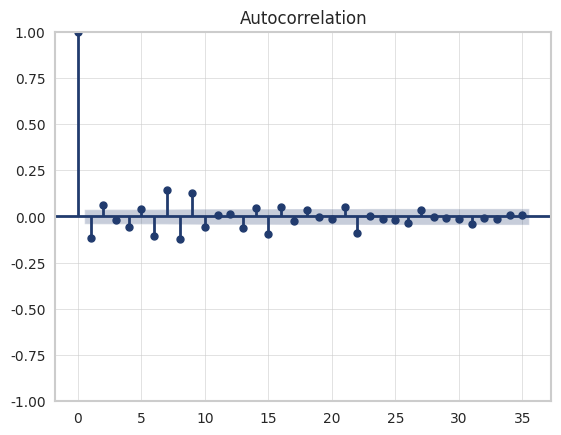

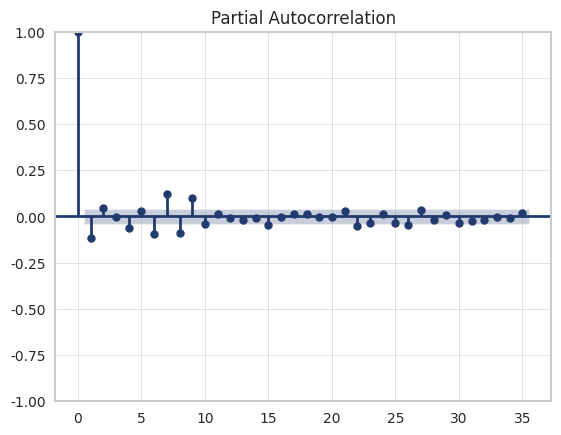

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(spy['return'])
plot_pacf(spy['return'])
plt.show()

In [ ]:
#@title 특성 공학
def engineer(df):
  df = df.astype('float')

  #5일 단순이동평균(sma)
  df['sma5'] = df['Close'].rolling(window=5, min_periods=1).mean()


  #5일 지수이동평균(ema)
  df['ema5'] = df['Close'].ewm(5).mean()
  #20일 지수이동평균
  df['ema20'] = df['Close'].ewm(20).mean()

  #이격도
  df['disparity'] = df['Close'] - df['sma5']

  #Stochastic K, D : Fast %K의 m기간 이동평균(SMA)
  df['fast_k'] = ((df['Close'] - df['Low'].rolling(5).min()) / (df['High'].rolling(5).max() - df['Low'].rolling(5).min())) * 100
  df['Slow_k'] = df['fast_k'].rolling(3).mean()
  df['Slow_d'] = df['Slow_k'].rolling(3).mean()

  #MACD
  df['EMAFast'] = df['Close'].ewm( span = 5, min_periods = 4).mean()
  df['EMASlow'] = df['Close'].ewm( span = 20, min_periods = 19).mean()
  df['MACD'] = df['EMAFast'] - df['EMASlow']
  #df['MACDSignal'] = df['MACD'].ewm( span = 9, min_periods = 8).mean()
  #df['MACDDiff'] = df['MACD'] - df['MACDSignal']

  #RSI
  delta = df['Close'].diff(5)
  delta = delta.dropna()

  up = delta.copy()
  down = delta.copy()

  up[up<0] = 0
  down[down>0] = 0

  df['up'] = up
  df['down'] = down

  AVG_Gain = df['up'].rolling(window = 5).mean()
  AVG_Loss = abs(df['down'].rolling(window = 5).mean())
  RS = AVG_Gain/AVG_Loss

  RSI = 100.0 - (100.0/(1+RS))
  df['RSI'] = RSI

  df['Diff'] =  np.r_[0, np.diff(df['Close'])]

  df = df.drop(columns=['Open', 'Close', 'High','Low', 'fast_k', 'EMAFast', 'EMASlow', 'up', 'down'])
  df = df.dropna()

  df = df.reset_index() #time_series_split할 때 필요


  return df

**모델 생성**

지난 과제를 통해서 주가 예측을 회귀 모델로 할 경우 r2 score가 높더라도 예측 가격이 실제 가격이랑 많이 다르게 나와서 분석이 어렵다고 느꼈습니다. 그렇지만 일단 분류문제로 풀기 전에 회귀분석으로 예측을 해서 수익률 예측을 해보겠습니다.

**회귀분석 모델**

* 모델 1: 다중선형회귀모델

* 모델 2: XGBoost 모델

* 모델 3: ARIMA 모델

회귀분석 모델 3가지를 만들 것인데, 타겟은 일일 종가의 차분으로 하고, 평가지표는 MSE, R2 score 두 가지를 사용하겠습니다.

In [ ]:
#@title 테스트 데이터 분리
len(spy)*0.2

503.0

In [ ]:
spy.columns = spy.columns.get_level_values(0)
spytest = spy[-503:]
spytrain = spy.drop(index=spytest.index)
spytrain.shape, spytest.shape

((2012, 8), (503, 8))

In [ ]:
#특성 공학
spytrain = engineer(spytrain)
spytest = engineer(spytest)

In [ ]:
print(spytrain.columns)

Index(['Date', 'Adj Close', 'Volume', 'Diff', 'return', 'sma5', 'ema5',
       'ema20', 'disparity', 'Slow_k', 'Slow_d', 'MACD', 'RSI'],
      dtype='object', name='Price')


In [ ]:
spytrain = spytrain.drop(columns=['return'])
spytest = spytest.drop(columns=['return'])

In [ ]:
#@title 모델 1 다중선형회귀분석

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=10)

target = 'Diff'
y = spytrain[target]
X = spytrain.drop(columns = target)

X = X.dropna()
y= y.dropna()

X = X.drop(columns='Date')

pred1 = []
scores = []
mses = []
for train_index, val_index in tscv.split(spytrain):

    X_train   = X.iloc[train_index] #drop('Date', axis=1)
    y_train = y.iloc[train_index]

    X_val    = X.iloc[val_index]
    y_val  = y.iloc[val_index]


    ols = LinearRegression()
    ols.fit(X_train,y_train)

    preds = ols.predict(X_val)
    pred1.append(preds)
    mse = mean_squared_error(y_val, preds)
    r2score = ols.score(X_val,y_val)
    mses.append(mse)
    scores.append(r2score)

average_r2score = np.mean(scores)
print(average_r2score)
print(np.mean(mses))

0.4644049436509656
4.904491757573121


In [ ]:
print("평균 r2 점수: ", average_r2score)
print("평균 mse:",np.mean(mses))

평균 r2 점수:  0.4644049436509656
평균 mse: 4.904491757573121


In [ ]:
scores

[0.005308192170997095,
 -0.11172988807105777,
 -0.09491782253714476,
 0.6795301666763978,
 0.682145723536524,
 0.7349853408596485,
 0.6907355188456696,
 0.6818066127884852,
 0.7039942808088873,
 0.672191311431249]

<Axes: >

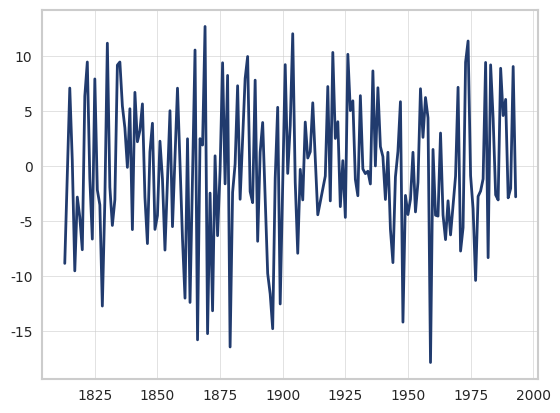

In [ ]:
y_val.plot()

In [ ]:
new_df1 = spy[(spy.index >= '2021-05-29')&(spy.index <= '2022-02-20')]
new_df1

Price,Adj Close,Close,High,Low,Open,Volume,Diff,return
Date,,,,,,,,
2021-06-01 00:00:00+00:00,398.988983,419.670013,422.720001,419.200012,422.570007,54216600.0,-0.369995,-0.088086
2021-06-02 00:00:00+00:00,399.616333,420.329987,421.230011,419.290009,420.369995,49097100.0,0.659973,0.157260
2021-06-03 00:00:00+00:00,398.133240,418.769989,419.989990,416.279999,417.850006,58138800.0,-1.559998,-0.371136
2021-06-04 00:00:00+00:00,401.774567,422.600006,422.920013,418.839996,420.750000,55938800.0,3.830017,0.914587
2021-06-07 00:00:00+00:00,401.384735,422.190002,422.779999,421.190002,422.589996,51555000.0,-0.410004,-0.097019
...,...,...,...,...,...,...,...,...
2022-02-14 00:00:00+00:00,421.568298,439.019989,441.600006,435.339996,439.920013,123006300.0,-1.440002,-0.326931
2022-02-15 00:00:00+00:00,428.366882,446.100006,446.279999,443.179993,443.730011,88482700.0,7.080017,1.612687
2022-02-16 00:00:00+00:00,428.846985,446.600006,448.059998,441.940002,443.929993,84863600.0,0.500000,0.112082


In [ ]:
new_df2 = new_df1.drop(columns=['Adj Close','Open','High','Low','Volume','Diff','return'])

In [ ]:
val_pred = pd.DataFrame(pred1).T
val_pred

,0,1,2,3,4,5,6,7,8,9
0,-7.030107,-0.518919,0.240160,-0.762358,-0.336177,3.878916,1.373383,-5.438217,1.199264,-10.196190
1,1.793674,2.059254,0.269003,0.323626,1.678813,1.849258,0.521165,-9.633328,0.772822,-6.469568
2,3.219956,0.179118,1.016520,-0.886706,0.930218,1.452848,1.091310,0.649416,1.087371,2.021685
3,-0.469158,0.508799,-0.346666,-0.240323,-0.199277,1.447153,0.592730,-3.665479,0.630252,0.551422
4,-1.752013,0.297137,-0.787717,-0.792554,0.343223,1.939120,0.510494,-1.109230,1.263551,-8.244989
...,...,...,...,...,...,...,...,...,...,...
176,4.514828,-0.221751,-2.025029,-0.471167,-0.915050,-0.177274,3.716689,-1.505266,-0.268956,6.132203
177,3.771083,-1.927946,-1.819365,1.662297,1.995790,0.773948,1.263481,3.526910,-0.777490,-0.289335
178,5.291134,-2.791959,-1.531781,2.849563,0.353571,2.945349,3.350406,1.972378,2.576617,-3.032379
179,2.333095,-3.370883,-1.833111,3.287792,0.997497,1.748703,6.223336,4.343693,5.820487,4.332145


In [ ]:
val_pred.iloc[0,:] = val_pred.iloc[0,:] + 419.670013
val_pred

,0,1,2,3,4,5,6,7,8,9
0,412.639906,419.151094,419.910173,418.907655,419.333836,423.548929,421.043396,414.231796,420.869277,409.473823
1,1.793674,2.059254,0.269003,0.323626,1.678813,1.849258,0.521165,-9.633328,0.772822,-6.469568
2,3.219956,0.179118,1.016520,-0.886706,0.930218,1.452848,1.091310,0.649416,1.087371,2.021685
3,-0.469158,0.508799,-0.346666,-0.240323,-0.199277,1.447153,0.592730,-3.665479,0.630252,0.551422
4,-1.752013,0.297137,-0.787717,-0.792554,0.343223,1.939120,0.510494,-1.109230,1.263551,-8.244989
...,...,...,...,...,...,...,...,...,...,...
176,4.514828,-0.221751,-2.025029,-0.471167,-0.915050,-0.177274,3.716689,-1.505266,-0.268956,6.132203
177,3.771083,-1.927946,-1.819365,1.662297,1.995790,0.773948,1.263481,3.526910,-0.777490,-0.289335
178,5.291134,-2.791959,-1.531781,2.849563,0.353571,2.945349,3.350406,1.972378,2.576617,-3.032379
179,2.333095,-3.370883,-1.833111,3.287792,0.997497,1.748703,6.223336,4.343693,5.820487,4.332145


In [ ]:
val_pred2 = val_pred.cumsum()

In [ ]:
val_pred2 = round(val_pred2, 1)
val_pred2

,0,1,2,3,4,5,6,7,8,9
0,412.6,419.2,419.9,418.9,419.3,423.5,421.0,414.2,420.9,409.5
1,414.4,421.2,420.2,419.2,421.0,425.4,421.6,404.6,421.6,403.0
2,417.7,421.4,421.2,418.3,421.9,426.9,422.7,405.2,422.7,405.0
3,417.2,421.9,420.8,418.1,421.7,428.3,423.2,401.6,423.4,405.6
4,415.4,422.2,420.1,417.3,422.1,430.2,423.8,400.5,424.6,397.3
...,...,...,...,...,...,...,...,...,...,...
176,614.7,243.5,299.1,421.6,361.1,500.5,459.8,589.6,331.2,119.1
177,618.4,241.5,297.3,423.3,363.1,501.3,461.1,593.2,330.5,118.8
178,623.7,238.8,295.8,426.1,363.5,504.2,464.4,595.1,333.0,115.7
179,626.1,235.4,293.9,429.4,364.5,506.0,470.6,599.5,338.9,120.1


In [ ]:
val_pred2['avg'] = val_pred2.mean(axis=1)
val_pred2

,0,1,2,3,4,5,6,7,8,9,avg
0,412.6,419.2,419.9,418.9,419.3,423.5,421.0,414.2,420.9,409.5,417.90
1,414.4,421.2,420.2,419.2,421.0,425.4,421.6,404.6,421.6,403.0,417.22
2,417.7,421.4,421.2,418.3,421.9,426.9,422.7,405.2,422.7,405.0,418.30
3,417.2,421.9,420.8,418.1,421.7,428.3,423.2,401.6,423.4,405.6,418.18
4,415.4,422.2,420.1,417.3,422.1,430.2,423.8,400.5,424.6,397.3,417.35
...,...,...,...,...,...,...,...,...,...,...,...
176,614.7,243.5,299.1,421.6,361.1,500.5,459.8,589.6,331.2,119.1,394.02
177,618.4,241.5,297.3,423.3,363.1,501.3,461.1,593.2,330.5,118.8,394.85
178,623.7,238.8,295.8,426.1,363.5,504.2,464.4,595.1,333.0,115.7,396.03
179,626.1,235.4,293.9,429.4,364.5,506.0,470.6,599.5,338.9,120.1,398.44


<Axes: xlabel='Date'>

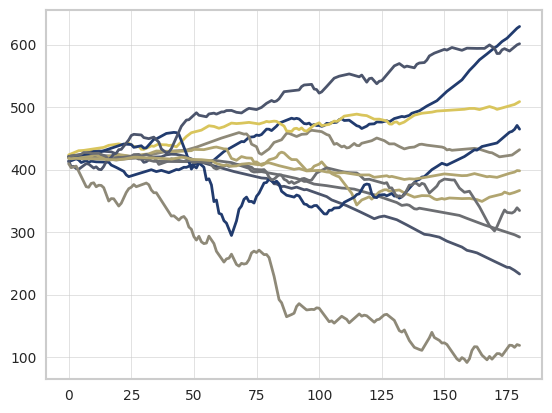

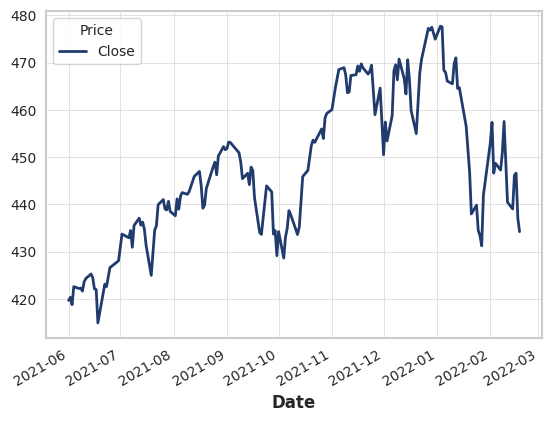

In [ ]:
val_pred2.iloc[:,0].plot()
val_pred2.iloc[:,1].plot()
val_pred2.iloc[:,2].plot()
val_pred2.iloc[:,3].plot()
val_pred2.iloc[:,4].plot()
val_pred2.iloc[:,5].plot()
val_pred2.iloc[:,6].plot()
val_pred2.iloc[:,7].plot()
val_pred2.iloc[:,8].plot()
val_pred2.iloc[:,9].plot()
val_pred2.iloc[:, 10].plot()
new_df2.plot()

In [ ]:
# val_pred2.index = new_df2.index
val_pred2.index = new_df2.index[:len(val_pred2)]

In [ ]:
plot_df = pd.concat([new_df2['Close'], val_pred2['avg']], axis=1)
plot_df

,Close,avg
Date,,
2021-06-01 00:00:00+00:00,419.670013,417.90
2021-06-02 00:00:00+00:00,420.329987,417.22
2021-06-03 00:00:00+00:00,418.769989,418.30
2021-06-04 00:00:00+00:00,422.600006,418.18
2021-06-07 00:00:00+00:00,422.190002,417.35
...,...,...
2022-02-14 00:00:00+00:00,439.019989,398.44
2022-02-15 00:00:00+00:00,446.100006,398.04
2022-02-16 00:00:00+00:00,446.600006,NaN


<Axes: xlabel='Date'>

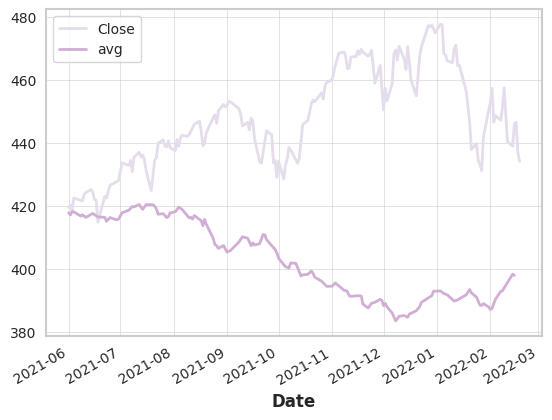

In [ ]:
sns.set_palette('PuRd')
plot_df.plot()

cv로 예측한 값들의 평균과 실제 종가의 그래프입니다. 실제 종가가 2021년 6월부터 증가하기 시작하는데 선형모델은 이를 전혀 예측하지 못합니다. 또한, 차분를 예측한 후 이를 누적합해서 종가를 만든 것이기 때문에 차분의 오차가 점점 쌓여서 실제 값과 더욱더 괴리되는 모습을 확인할 수 있습니다. 이런 급증이 있는 경우 모델 성능이 더 떨어지기 때문에 검증 데이터의 값에 따라 모델의 성능이 많이 차이날 것 같습니다.

모델 1의 예측에 중요한 영향을 미친 특성중요도를 살펴보겠습니다.

In [ ]:
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107721 sha256=f415540168dadf630b8ea8614bac5885039336da0115f8907e2385872e4ef1c0
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [ ]:
import sklearn
sklearn.__version__

'1.5.2'

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import eli5
from eli5.sklearn import PermutationImportance

# permuter 정의
permuter = PermutationImportance(
    ols,
    scoring='r2', # metric
    n_iter=5, # 다른 random seed를 사용하여 5번 반복
    random_state=2
)


permuter.fit(X_val, y_val);


feature_names = X_val.columns.tolist()
eli5.show_weights(
    permuter,
    top=None, # top n 지정 가능, None 일 경우 모든 특성
    feature_names=feature_names # list 형식으로 넣어야 합니다
)

ImportError: cannot import name 'if_delegate_has_method' from 'sklearn.utils.metaestimators' (/usr/local/lib/python3.10/dist-packages/sklearn/utils/metaestimators.py)

In [ ]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import sklearn
sklearn.__version__

'1.5.2'

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Fit the model on training data (assuming 'ols' is your trained model)
ols.fit(X_train, y_train)

# Compute permutation importances on validation set
result = permutation_importance(ols, X_val, y_val, n_repeats=5, random_state=2, scoring='r2')

# Convert to DataFrame for a clearer display
importance_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance': result.importances_mean,
    'std_dev': result.importances_std
}).sort_values(by='importance', ascending=False)

# Display the importance DataFrame
print(importance_df)

     feature  importance   std_dev
2       sma5   85.918712  3.666281
3       ema5   35.937436  1.980705
8       MACD    7.925125  0.360178
4      ema20    7.425692  0.609270
5  disparity    3.903204  0.171679
6     Slow_k    0.167586  0.013612
0  Adj Close    0.051977  0.005046
7     Slow_d    0.007014  0.001202
1     Volume    0.000564  0.000451
9        RSI   -0.004696  0.002268


In [ ]:
def manual_permutation_importance(model, X_val, y_val, metric=r2_score, n_repeats=5, random_state=2):
    np.random.seed(random_state)
    baseline_score = metric(y_val, model.predict(X_val))  # Calculate baseline metric score
    importances = np.zeros(X_val.shape[1])  # Initialize array for importances
    feature_names = X_val.columns

    for i, col in enumerate(feature_names):
        scores = np.zeros(n_repeats)

        for n in range(n_repeats):
            X_permuted = X_val.copy()
            X_permuted[col] = np.random.permutation(X_permuted[col].values)  # Shuffle column
            permuted_score = metric(y_val, model.predict(X_permuted))  # Calculate score with shuffled column
            scores[n] = baseline_score - permuted_score  # Difference from baseline

        importances[i] = np.mean(scores)  # Mean importance over repeats

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    return importance_df

# Assuming 'ols' is your trained model
ols.fit(X_train, y_train)
importance_df = manual_permutation_importance(ols, X_val, y_val)
print(importance_df)

NameError: name 'r2_score' is not defined

In [ ]:
# SHAP

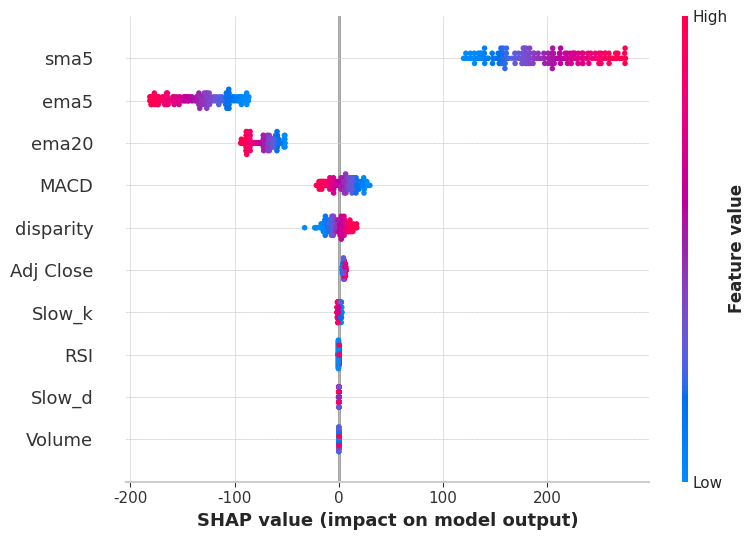

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fit the model on training data (assuming 'ols' is your trained model)
ols.fit(X_train, y_train)

# Initialize the SHAP explainer with the model and training data
explainer = shap.Explainer(ols, X_train)

# Calculate SHAP values for the validation set
shap_values = explainer(X_val)

# Create a summary plot of the SHAP values
shap.summary_plot(shap_values.values, X_val, feature_names=X_val.columns, plot_type="dot")

# Alternatively, you can use the following if you want SHAP to handle the dataframe automatically:
# shap.summary_plot(shap_values, X_val)


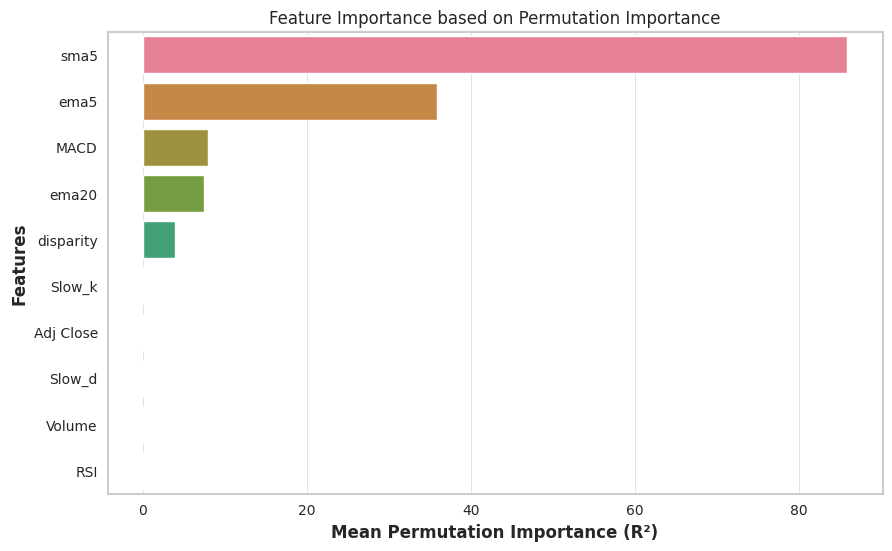

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model on training data (assuming 'ols' is your trained model)
ols.fit(X_train, y_train)

# Compute permutation importances on the validation set
result = permutation_importance(ols, X_val, y_val, n_repeats=5, random_state=2, scoring='r2')

# Convert results to a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({
    'Feature Id': X_val.columns,
    'Importances': result.importances_mean
}).sort_values(by='Importances', ascending=False)

# Plotting with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=feature_importance_df, palette="husl")
plt.title('Feature Importance based on Permutation Importance')
plt.xlabel("Mean Permutation Importance (R²)")
plt.ylabel("Features")
plt.show()


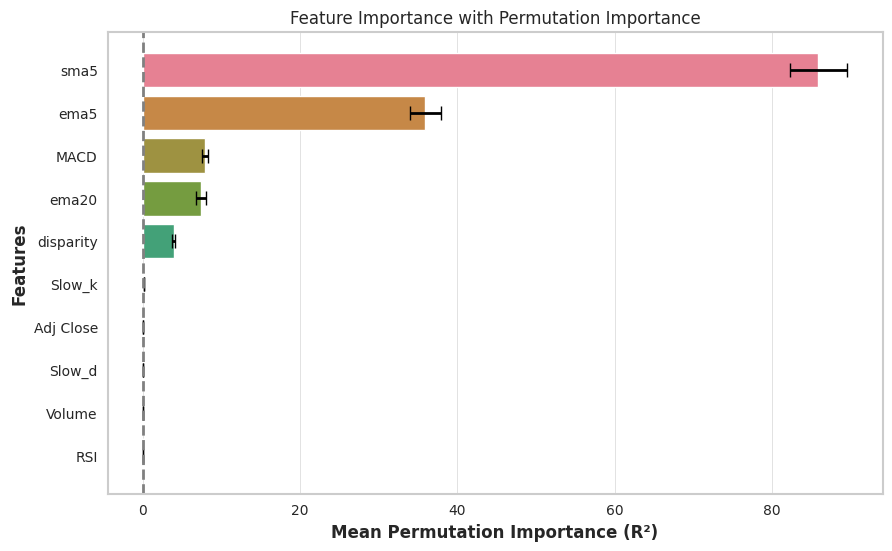

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model on training data (assuming 'ols' is your trained model)
ols.fit(X_train, y_train)

# Compute permutation importances on the validation set
result = permutation_importance(ols, X_val, y_val, n_repeats=5, random_state=2, scoring='r2')

# Convert results to a DataFrame for easier plotting, including both mean and standard deviation
feature_importance_df = pd.DataFrame({
    'Feature Id': X_val.columns,
    'Importances': result.importances_mean,
    'std_dev': result.importances_std
}).sort_values(by='Importances', ascending=False)

# Plotting with seaborn, including negative part using error bars
plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=feature_importance_df, palette="husl", orient='h')

# Adding error bars to show variability (positive and negative influence)
plt.errorbar(feature_importance_df['Importances'], feature_importance_df['Feature Id'],
             xerr=feature_importance_df['std_dev'], fmt='none', c='black', capsize=5)

# Customizing plot appearance
plt.title('Feature Importance with Permutation Importance')
plt.xlabel("Mean Permutation Importance (R²)")
plt.ylabel("Features")
plt.axvline(x=0, color='grey', linestyle='--')  # Add a vertical line at x=0 for reference
plt.show()


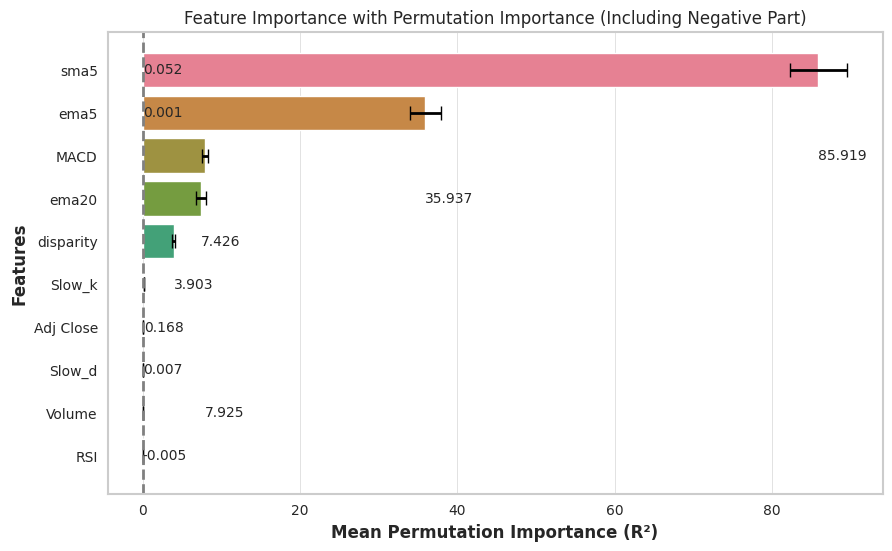

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model on training data (assuming 'ols' is your trained model)
ols.fit(X_train, y_train)

# Compute permutation importances on the validation set
result = permutation_importance(ols, X_val, y_val, n_repeats=5, random_state=2, scoring='r2')

# Convert results to a DataFrame for easier plotting, including both mean and standard deviation
feature_importance_df = pd.DataFrame({
    'Feature Id': X_val.columns,
    'Importances': result.importances_mean,
    'std_dev': result.importances_std
}).sort_values(by='Importances', ascending=False)

# Plotting with seaborn, including negative part using error bars
plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=feature_importance_df, palette="husl", orient='h')

# Adding error bars to show variability (positive and negative influence)
plt.errorbar(feature_importance_df['Importances'], feature_importance_df['Feature Id'],
             xerr=feature_importance_df['std_dev'], fmt='none', c='black', capsize=5)

# Add annotations for each bar to show the numeric value
for index, row in feature_importance_df.iterrows():
    plt.text(row['Importances'], index, f"{row['Importances']:.3f}", va='center')

# Customizing plot appearance
plt.title('Feature Importance with Permutation Importance (Including Negative Part)')
plt.xlabel("Mean Permutation Importance (R²)")
plt.ylabel("Features")
plt.axvline(x=0, color='grey', linestyle='--')  # Add a vertical line at x=0 for reference
plt.show()


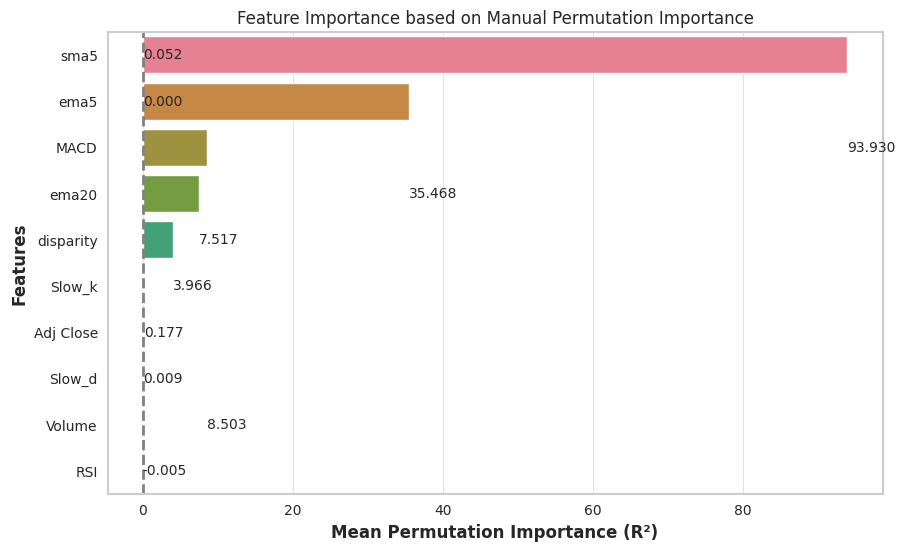

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Custom permutation importance function
def manual_permutation_importance(model, X_val, y_val, metric=r2_score, n_repeats=5, random_state=2):
    np.random.seed(random_state)
    baseline_score = metric(y_val, model.predict(X_val))  # Calculate baseline metric score
    importances = np.zeros(X_val.shape[1])  # Initialize array for importances
    feature_names = X_val.columns

    for i, col in enumerate(feature_names):
        scores = np.zeros(n_repeats)

        for n in range(n_repeats):
            X_permuted = X_val.copy()
            X_permuted[col] = np.random.permutation(X_permuted[col].values)  # Shuffle column
            permuted_score = metric(y_val, model.predict(X_permuted))  # Calculate score with shuffled column
            scores[n] = baseline_score - permuted_score  # Difference from baseline

        importances[i] = np.mean(scores)  # Mean importance over repeats

    importance_df = pd.DataFrame({
        'Feature Id': feature_names,
        'Importances': importances
    }).sort_values(by='Importances', ascending=False)

    return importance_df

# Assuming 'ols' is your trained model
ols.fit(X_train, y_train)

# Calculate feature importances using the manual function
importance_df = manual_permutation_importance(ols, X_val, y_val)

# Plotting with seaborn, including numeric values on each bar
plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=importance_df, palette="husl", orient='h')

# Adding annotations for each bar to show the numeric value
for index, row in importance_df.iterrows():
    plt.text(row['Importances'], index, f"{row['Importances']:.3f}", va='center')

# Customizing plot appearance
plt.title('Feature Importance based on Manual Permutation Importance')
plt.xlabel("Mean Permutation Importance (R²)")
plt.ylabel("Features")
plt.axvline(x=0, color='grey', linestyle='--')  # Add a vertical line at x=0 for reference
plt.show()


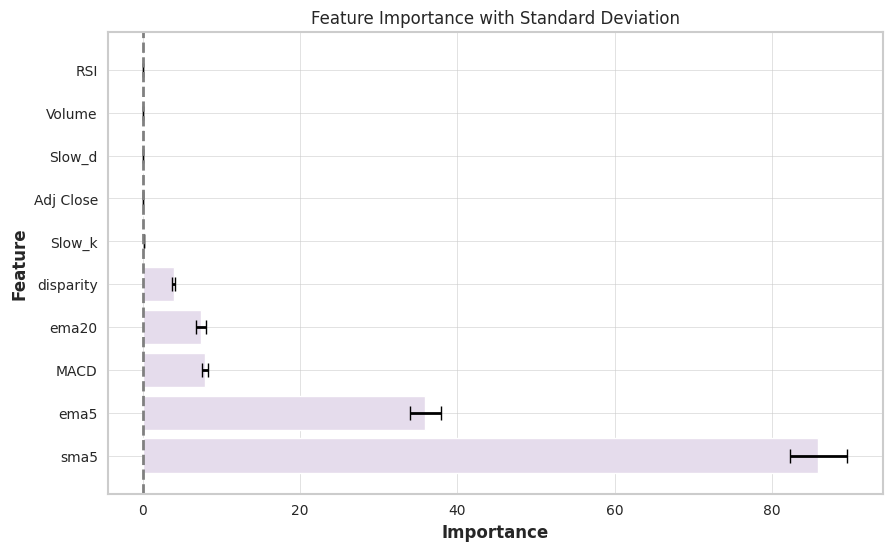

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Provided data
data = {
    'feature': ['sma5', 'ema5', 'MACD', 'ema20', 'disparity', 'Slow_k', 'Adj Close', 'Slow_d', 'Volume', 'RSI'],
    'importance': [85.918737, 35.937439, 7.925124, 7.425690, 3.903206, 0.167586, 0.051977, 0.007014, 0.000564, -0.004696],
    'std_dev': [3.666282, 1.980705, 0.360178, 0.609270, 0.171679, 0.013612, 0.005046, 0.001202, 0.000451, 0.002268]
}

# Create DataFrame
importance_df = pd.DataFrame(data).sort_values(by='importance', ascending=False)

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], xerr=importance_df['std_dev'], capsize=5)
plt.axvline(x=0, color='grey', linestyle='--')  # Reference line at 0 for positive/negative distinction
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance with Standard Deviation")

plt.show()


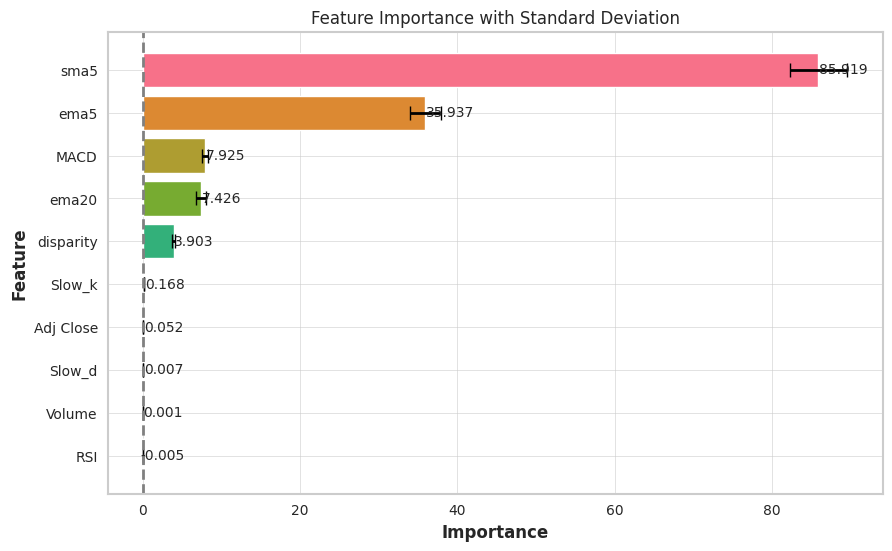

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Provided data
data = {
    'feature': ['sma5', 'ema5', 'MACD', 'ema20', 'disparity', 'Slow_k', 'Adj Close', 'Slow_d', 'Volume', 'RSI'],
    'importance': [85.918737, 35.937439, 7.925124, 7.425690, 3.903206, 0.167586, 0.051977, 0.007014, 0.000564, -0.004696],
    'std_dev': [3.666282, 1.980705, 0.360178, 0.609270, 0.171679, 0.013612, 0.005046, 0.001202, 0.000451, 0.002268]
}

# Create DataFrame and sort by importance
importance_df = pd.DataFrame(data).sort_values(by='importance', ascending=False)

# Set the husl color palette
colors = sns.color_palette("husl", len(importance_df))

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['feature'], importance_df['importance'], xerr=importance_df['std_dev'], capsize=5, color=colors)
plt.axvline(x=0, color='grey', linestyle='--')  # Reference line at 0 for positive/negative distinction
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance with Standard Deviation")

# Adding text annotations for the importance values
for bar, importance in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + (0.1 if importance >= 0 else -0.3),
             bar.get_y() + bar.get_height()/2,
             f"{importance:.3f}",
             va='center')

plt.gca().invert_yaxis()  # Ensure the largest value is at the top
plt.show()


모델 1에서 차분(Difference)를 예측하는 데 가장 중요한 특성으로는 단순이동평균(5일), 지수이동평균(5일), MACD, 지수이동평균(20일), 이격도가 있습니다. 이동평균이 높은 순위를 차지하고 있는데, 차분이 종가의 하루 차이인 것을 생각해보면, 단순이동평균은 5일 간의 평균이기 때문에 약간의 leakeage가 있다고 볼 수도 있습니다. 그런데 대부분의 랜덤워크 모형은 가격에서 파생된 특성으로 예측을 해서 모형 특성상 발생하는 애매한 부분인 것 같습니다.

## 모델 2 XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
'''
target = 'Diff'
y =spytrain[target]
X =spytrain.drop(columns = target)

X = X.dropna()
y= y.dropna()

X = X.drop(columns='Date')
'''
scores_xgb = []
mse_xgb = []
preds_xgb = []

for train_index, val_index in tscv.split(spytrain):

    X_train2   = X.iloc[train_index] #drop('Date', axis=1)
    y_train2 = y.iloc[train_index]

    X_val2  = X.iloc[val_index] #.drop('record_date', axis=1)
    y_val2  = y.iloc[val_index]

    # if needed, do preprocessing here

    xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.08, gamma=0,
                            max_depth=7)
    xgb_model.fit(X_train2, y_train2)

    pred_xgb = xgb_model.predict(X_val2)
    preds_xgb.append(pred_xgb)

    r2score_xgb = xgb_model.score(X_val2,y_val2)
    scores_xgb.append(r2score_xgb)

    mse_xg = mean_squared_error(y_val2, pred_xgb)
    mse_xgb.append(mse_xg)
average_r2score_xgb = np.mean(scores_xgb)
print("평균 r2 score: ",average_r2score_xgb)
print("평균 mse: ",np.mean(mse_xgb))

평균 r2 score:  0.5704747711301972
평균 mse:  6.07326562554057


In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

# permuter 정의
permuter2 = PermutationImportance(
    xgb_model,
    scoring='r2', # metric
    n_iter=5,
    random_state=2
)


permuter2.fit(X_val2, y_val2);


feature_names2 = X_val2.columns.tolist()
eli5.show_weights(
    permuter2,
    top=None,
    feature_names=feature_names2
)

ImportError: cannot import name 'if_delegate_has_method' from 'sklearn.utils.metaestimators' (/usr/local/lib/python3.10/dist-packages/sklearn/utils/metaestimators.py)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def manual_permutation_importance(model, X_val, y_val, metric=r2_score, n_repeats=5, random_state=2):
    np.random.seed(random_state)

    # Calculate the baseline score with the original data
    baseline_score = metric(y_val, model.predict(X_val))

    # Initialize an array to store importances for each feature
    importances = np.zeros(X_val.shape[1])
    feature_names = X_val.columns

    # Loop through each feature to calculate permutation importance
    for i, col in enumerate(feature_names):
        scores = np.zeros(n_repeats)

        for n in range(n_repeats):
            # Permute the values in the current feature column
            X_permuted = X_val.copy()
            X_permuted[col] = np.random.permutation(X_permuted[col].values)

            # Calculate the model's score with the permuted feature
            permuted_score = metric(y_val, model.predict(X_permuted))

            # Calculate the drop in score from the baseline
            scores[n] = baseline_score - permuted_score

        # The importance of a feature is the average drop in score across repeats
        importances[i] = np.mean(scores)

    # Create a DataFrame to display feature importances
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    return importance_df

# Assuming 'xgb_model' is your trained model
xgb_model.fit(X_train, y_train)  # Fit the model with training data
importance_df = manual_permutation_importance(xgb_model, X_val2, y_val2)

# Display the importance DataFrame
print(importance_df)


     feature  importance
5  disparity    1.831752
6     Slow_k    0.318558
1     Volume    0.047758
8       MACD    0.039615
7     Slow_d    0.017671
9        RSI    0.009462
0  Adj Close    0.003747
4      ema20    0.000280
3       ema5    0.000074
2       sma5   -0.000063


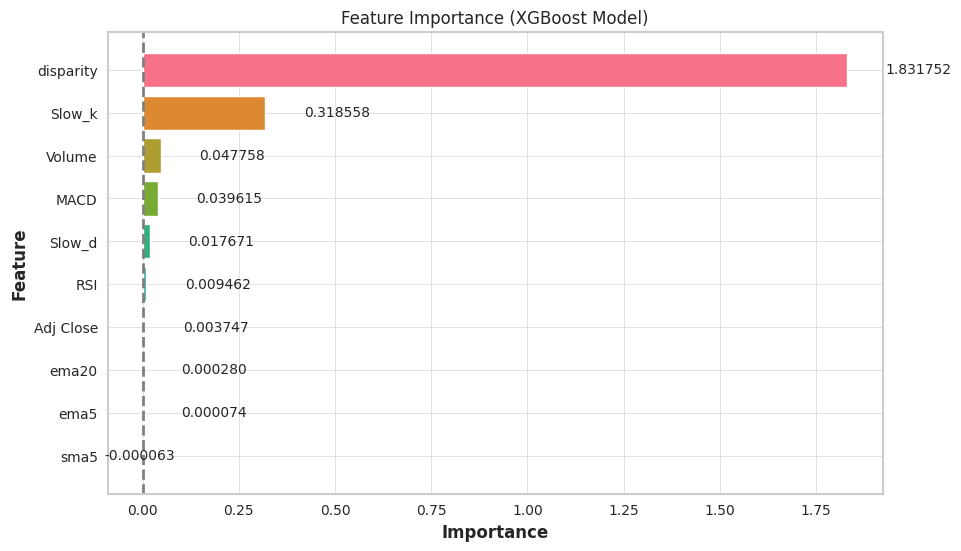

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Provided data
data = {
    'feature': ['disparity', 'Slow_k', 'Volume', 'MACD', 'Slow_d', 'RSI', 'Adj Close', 'ema20', 'ema5', 'sma5'],
    'importance': [1.831752, 0.318558, 0.047758, 0.039615, 0.017671, 0.009462, 0.003747, 0.000280, 0.000074, -0.000063]
}

# Create DataFrame and sort by importance
importance_df = pd.DataFrame(data).sort_values(by='importance', ascending=False)

# Set the husl color palette
colors = sns.color_palette("husl", len(importance_df))

# Plotting with matplotlib
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.axvline(x=0, color='grey', linestyle='--')  # Reference line at 0 for positive/negative distinction
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (XGBoost Model)")

# Adding text annotations for the importance values
for bar, importance in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + (0.1 if importance >= 0 else -0.1),
             bar.get_y() + bar.get_height()/2,
             f"{importance:.6f}",
             va='center')

plt.gca().invert_yaxis()  # Ensure the largest value is at the top
plt.show()


모델 2에서 차분(Difference)을 예측하는 데 가장 중요한 특성으로는 이격도, Stochastic %k, Volume, MACD, Stochastic %D가 있습니다. 이격도가 가장 중요한 특성으로 나왔는데, 이격도를 구하는데 종가와 이동평균이 필요한 것을 생각해보면 순위가 낮게 나온 sma5는 특성에서 제외해도 될 것 같습니다.

## 모델 3 ARIMA

시계열 예측에 많이 사용하는 ARIMA 모델을 사용해서 분석을 해보겠습니다. ARIMA 모델은 AR모델과 MA모델을 합친 것으로 p,d,q 세가지의 모수를 가집니다. p는 AR모형의 lag, d는 차분 횟수, q는 MA모형의 lag를 의미합니다. 정상성 확인하는 과정에서의 ACF, PACF 그래프를 보고 p = 1, d=1, q=0으로 유추하였습니다.

In [ ]:
#모델1,2에서 사용된 훈련 데이터 + 검증 데이터
arima_df = spy[(spy.index<='2022-11-21') & (spy.index>'2014-12-15')]

In [ ]:
from statsmodels.tsa.arima_model import ARIMA
mod = ARIMA(arima_df['Diff'], order=(1, 1, 0))
res = mod.fit(trend='c',full_output=True, disp=0)
print(res.summary())

NotImplementedError: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been removed in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and statsmodels.tsa.SARIMAX.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained. It also offers alternative specialized
parameter estimators.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define and fit the ARIMA model without a constant trend
mod = ARIMA(arima_df['Diff'], order=(1, 1, 0))
res = mod.fit()

# Display the model summary
print(res.summary())


                               SARIMAX Results                                
Dep. Variable:                   Diff   No. Observations:                 1998
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -5804.128
Date:                Sun, 10 Nov 2024   AIC                          11612.255
Time:                        12:12:55   BIC                          11623.454
Sample:                             0   HQIC                         11616.368
                               - 1998                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5686      0.009    -63.808      0.000      -0.586      -0.551
sigma2        19.5848      0.263     74.357      0.000      19.069      20.101
Ljung-Box (L1) (Q):                  72.47   Jarque-

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<Figure size 1000x500 with 0 Axes>

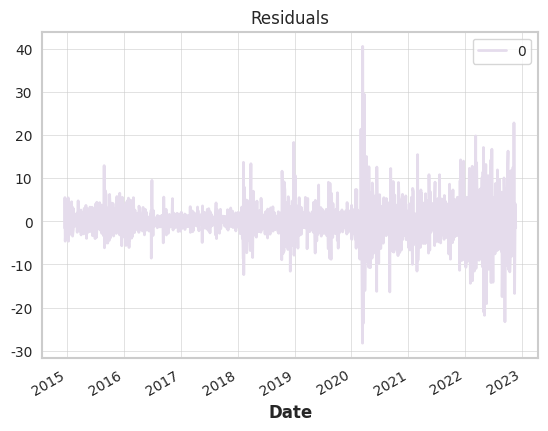

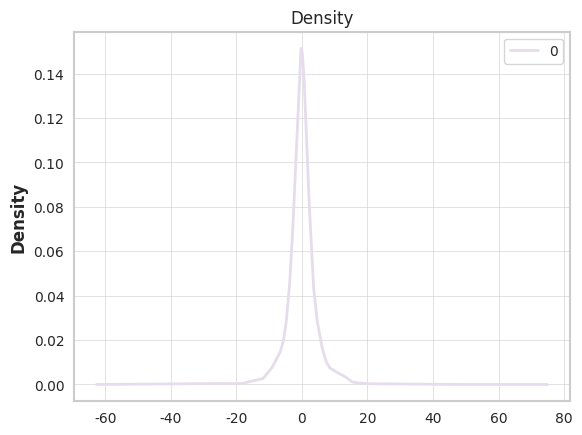

In [ ]:
residuals = pd.DataFrame(res.resid)
fig = plt.figure(figsize=(10,5))

#ax1 = fig.add_subplot(1, 2, 1)
ax1 = residuals.plot(title="Residuals")

#ax2 = fig.add_subplot(1, 2, 2)
ax2 = residuals.plot(kind='kde', title='Density')

plt.show()

In [ ]:
plt.style.use('ggplot')
res.plot_predict(dynamic=False)
plt.show()

AttributeError: 'ARIMAResults' object has no attribute 'plot_predict'

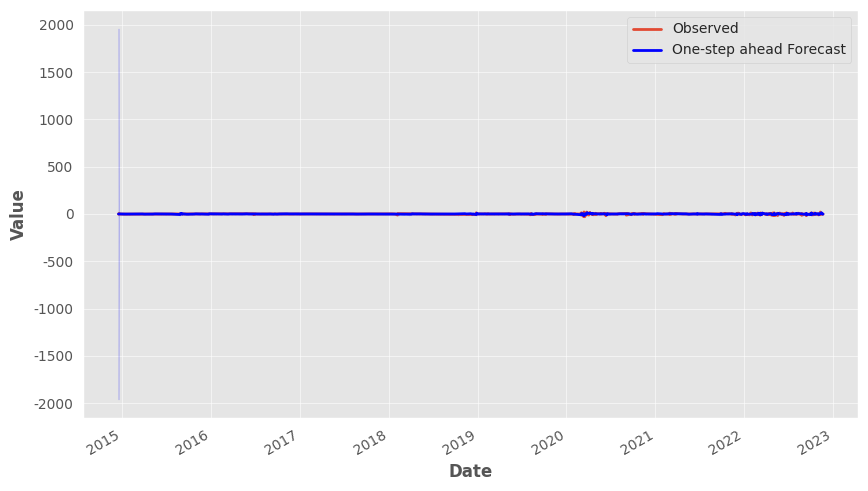

In [ ]:
import matplotlib.pyplot as plt

# Use ggplot style
plt.style.use('ggplot')

# In-sample prediction
pred = res.get_prediction(dynamic=False)
pred_ci = pred.conf_int()  # Get confidence intervals for the predictions

# Plot the observed data
arima_df['Diff'].plot(label='Observed', figsize=(10, 6))

# Plot the predicted mean
pred.predicted_mean.plot(label='One-step ahead Forecast', color='blue')

# Plot the confidence intervals
plt.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='blue', alpha=0.2)

# Show the plot
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


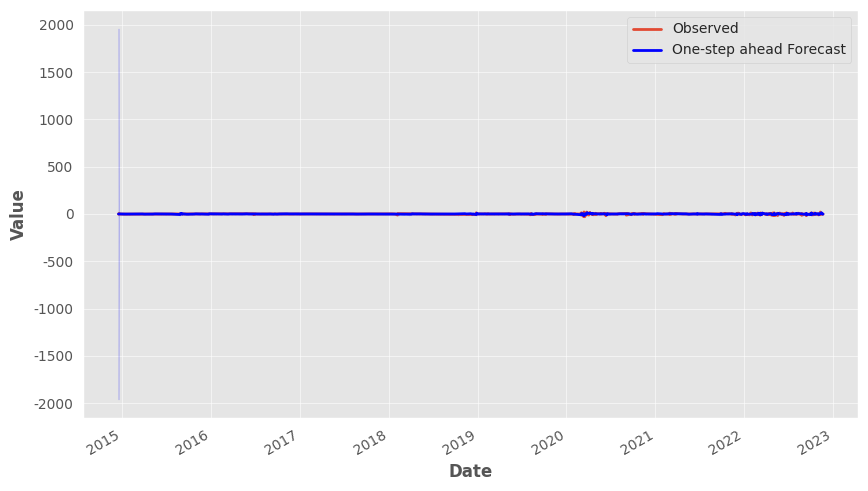

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# In-sample prediction with confidence intervals
pred = res.get_prediction(dynamic=False)
pred_ci = pred.conf_int()

# Plot observed data, predictions, and confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))
arima_df['Diff'].plot(ax=ax, label='Observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', color='blue')
ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='blue', alpha=0.2)

# Customize plot
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
plt.show()


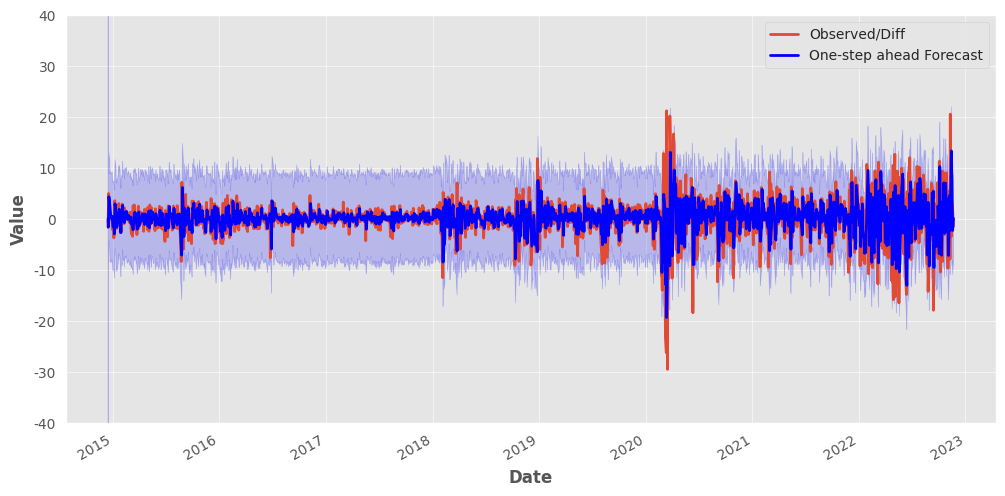

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# In-sample prediction with confidence intervals
pred = res.get_prediction(dynamic=False)
pred_ci = pred.conf_int()

# Plot observed data, predictions, and confidence intervals
fig, ax = plt.subplots(figsize=(12, 6))
arima_df['Diff'].plot(ax=ax, label='Observed/Diff')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', color='blue')
ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='blue', alpha=0.2)

# Set custom y-axis limits to reduce value range (adjust as needed)
ax.set_ylim(-40, 40)  # Example range; adjust based on your data

# Customize plot
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend()
plt.show()


ARIMA 모델로 예측한 값과 실제 차분의 그래프입니다. 이대로는 분석이 어렵고, 투명도 조절을 하거나 종가로 바꿔서 봐야할 것 같습니다.

이렇게 회귀분석 모델 세가지를 이용한 분석을 했는데, 회귀분석로는 의사결정 시그널을 주기 어려운 것 같습니다. 물론 차분을 예측해서 누적합을 하면 지수의 종가 예측값이 나오는데, 오차범위도 정해야 하고 모델이 너무 복잡해집니다.

이번엔 의사결정에 직접적으로 도움을 줄 수 있는 분류 모델로 다시 분석해 볼 것입니다.

## 모델 4 XGBoost Classifier

In [ ]:
def engineer2(df):
  df = df.astype('float')

  #5일 단순이동평균(sma)
  df['sma5'] = df['Close'].rolling(window=5, min_periods=1).mean()


  #5일 지수이동평균(ema)
  df['ema5'] = df['Close'].ewm(5).mean()
  #20일 지수이동평균
  df['ema20'] = df['Close'].ewm(20).mean()

  #이격도
  df['disparity'] = df['Close'] - df['sma5']

  #Stochastic K, D : Fast %K의 m기간 이동평균(SMA)
  df['fast_k'] = ((df['Close'] - df['Low'].rolling(5).min()) / (df['High'].rolling(5).max() - df['Low'].rolling(5).min())) * 100
  df['Slow_k'] = df['fast_k'].rolling(3).mean()
  df['Slow_d'] = df['Slow_k'].rolling(3).mean()

  #MACD
  df['EMAFast'] = df['Close'].ewm( span = 5, min_periods = 4).mean()
  df['EMASlow'] = df['Close'].ewm( span = 20, min_periods = 19).mean()
  df['MACD'] = df['EMAFast'] - df['EMASlow']
  #df['MACDSignal'] = df['MACD'].ewm( span = 9, min_periods = 8).mean()
  #df['MACDDiff'] = df['MACD'] - df['MACDSignal']

  #RSI
  delta = df['Close'].diff(5)
  delta = delta.dropna()

  up = delta.copy()
  down = delta.copy()

  up[up<0] = 0
  down[down>0] = 0

  df['up'] = up
  df['down'] = down

  AVG_Gain = df['up'].rolling(window = 5).mean()
  AVG_Loss = abs(df['down'].rolling(window = 5).mean())
  RS = AVG_Gain/AVG_Loss

  RSI = 100.0 - (100.0/(1+RS))
  df['RSI'] = RSI

  df['Diff'] =  np.r_[0, np.diff(df['Close'])]

  df = df.drop(columns=['Open', 'High','Low', 'fast_k', 'EMAFast', 'EMASlow', 'up', 'down'])
  df = df.dropna()

  df = df.reset_index() #time_series_split할 때 필요


  return df

In [ ]:
#타겟값 만들기
def define_target_condition(df):

    # price above trend multiple days later
    df['target_cls'] = np.where(df['Close'].shift(-20) > df.ema20.shift(-20), 1, 0)

    # important, remove NaN values
    df=df.fillna(0).copy()

    df.tail()

    return df

In [ ]:
spytest2 = spy[-503:]
spytrain2 = spy.drop(index=spytest2.index)
spytrain2.shape, spytest2.shape

((2012, 8), (503, 8))

In [ ]:
spytrain2 = engineer2(spytrain2)
spytest2 = engineer2(spytest2)
spytrain2 =define_target_condition(spytrain2)
spytest2 = define_target_condition(spytest2)

In [ ]:
spytrain2

Price,Date,Adj Close,Close,Volume,Diff,return,sma5,ema5,ema20,disparity,Slow_k,Slow_d,MACD,RSI,target_cls
0,2014-12-01 00:00:00+00:00,172.499893,205.759995,103968400.0,-1.440002,-0.694982,206.993997,206.151788,205.306911,-1.234003,58.115548,74.692305,0.875651,90.223174,1
1,2014-12-02 00:00:00+00:00,173.614899,207.089996,74507200.0,1.330002,0.646385,206.959998,206.312344,205.443177,0.129999,49.495221,62.441450,0.895085,83.707049,0
2,2014-12-03 00:00:00+00:00,174.285614,207.889999,68952000.0,0.800003,0.386307,207.115997,206.581129,205.624932,0.774002,58.183064,55.264611,1.055659,81.556709,0
3,2014-12-04 00:00:00+00:00,174.092712,207.660004,91316600.0,-0.229996,-0.110633,207.119998,206.764259,205.772175,0.540005,79.393737,62.357341,1.063417,68.945925,0
4,2014-12-05 00:00:00+00:00,174.377808,208.000000,91025500.0,0.339996,0.163727,207.279999,206.973372,205.929474,0.720001,84.765391,74.114064,1.109206,59.479727,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,2022-10-25 00:00:00+00:00,373.898376,384.920013,78846300.0,6.050018,1.596859,374.398004,371.970516,378.259379,10.522009,94.964150,81.211205,4.450932,98.981823,0
1990,2022-10-26 00:00:00+00:00,371.081390,382.019989,104087300.0,-2.900024,-0.753410,377.102002,373.645428,378.438455,4.917987,89.382828,87.239306,5.351261,99.010255,0
1991,2022-10-27 00:00:00+00:00,369.099823,379.980011,81971800.0,-2.039978,-0.533998,380.016003,374.701192,378.511863,-0.035992,81.245997,88.530992,5.238726,100.000000,0
1992,2022-10-28 00:00:00+00:00,377.880890,389.019989,100302000.0,9.039978,2.379067,382.962000,377.087658,379.012250,6.057990,80.737014,83.788613,7.156914,100.000000,0


In [ ]:
#@title 베이스라인
spytrain2['target_cls'].value_counts(normalize=True)

,proportion
target_cls,
1,0.69007
0,0.30993


In [ ]:
print('베이스라인 모델 검증 정확도: ', 0.69007)

베이스라인 모델 검증 정확도:  0.69007


In [ ]:
# Convert labels to binary (assuming binary classification is appropriate)
y_train2 = y_train2.apply(lambda x: 1 if x > 0 else 0)
y_val2 = y_val2.apply(lambda x: 1 if x > 0 else 0)


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Convert data into DMatrix format, required for xgb.train
dtrain = xgb.DMatrix(X_train2, label=y_train2)
dval = xgb.DMatrix(X_val2, label=y_val2)

# Set parameters for XGBoost model
params = {
    'objective': 'binary:logistic',   # Adjust according to your task
    'eval_metric': 'error',           # Error rate metric
    'eta': 0.1,                       # Learning rate
    'max_depth': 6                    # Adjust as needed
}

# Define evaluation set for monitoring performance
eval_set = [(dtrain, 'train'), (dval, 'validation')]

# Train the model with early stopping
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,            # Maximum rounds
    evals=eval_set,
    early_stopping_rounds=50         # Stops if no improvement in 50 rounds
)

# Predict on validation set for evaluation
y_pred = model.predict(dval)
y_pred_class = [1 if pred > 0.5 else 0 for pred in y_pred]  # Threshold for binary classification
accuracy = accuracy_score(y_val2, y_pred_class)
print("Validation Accuracy:", accuracy)


[0]	train-error:0.33756	validation-error:0.50276
[1]	train-error:0.18202	validation-error:0.24862
[2]	train-error:0.16327	validation-error:0.21547
[3]	train-error:0.15113	validation-error:0.22099
[4]	train-error:0.14948	validation-error:0.20994
[5]	train-error:0.15168	validation-error:0.20994
[6]	train-error:0.14562	validation-error:0.19337
[7]	train-error:0.14175	validation-error:0.20442
[8]	train-error:0.14175	validation-error:0.20994
[9]	train-error:0.13679	validation-error:0.20994
[10]	train-error:0.13679	validation-error:0.20994
[11]	train-error:0.13127	validation-error:0.21547
[12]	train-error:0.13514	validation-error:0.21547
[13]	train-error:0.13458	validation-error:0.21547
[14]	train-error:0.13238	validation-error:0.21547
[15]	train-error:0.13017	validation-error:0.20994
[16]	train-error:0.12410	validation-error:0.20994
[17]	train-error:0.12466	validation-error:0.20994
[18]	train-error:0.12521	validation-error:0.20994
[19]	train-error:0.12135	validation-error:0.20994
[20]	train

In [ ]:
spytrain2 = spytrain2.drop(columns = ['return','Diff'])

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np

target2 = 'target_cls'

y2 = spytrain2[target2]
X2 = spytrain2.drop(columns=target2)

# Drop rows with missing values in X2 and y2
X2 = X2.dropna()
y2 = y2.dropna()

# Drop 'Date' column if present
X2 = X2.drop(columns='Date', errors='ignore')

# Lists to store evaluation scores
scores_xgbc = []
preds_xgbc = []
f1_score_list = []
prec_score = []
rec_score = []

# Time series cross-validation loop
for train_index, val_index in tscv.split(spytrain2):
    X2_train = X2.iloc[train_index]
    y2_train = y2.iloc[train_index]
    X2_val = X2.iloc[val_index]
    y2_val = y2.iloc[val_index]

    # Define XGBClassifier with eval_metric in initialization
    xgb = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.08,
        gamma=0,
        max_depth=7,
        eval_metric='error'  # Set eval_metric here
    )

    # Define eval set for early stopping
    eval_set = [(X2_train, y2_train), (X2_val, y2_val)]

    # Fit the model with early stopping
    xgb.fit(
        X2_train,
        y2_train,
        eval_set=eval_set,
        #early_stopping_rounds=50
    )

    # Make predictions and calculate scores
    pred_xgbc = xgb.predict(X2_val)
    preds_xgbc.append(pred_xgbc)
    scores_xgbc.append(xgb.score(X2_val, y2_val))
    prec_score.append(precision_score(y2_val, pred_xgbc))
    rec_score.append(recall_score(y2_val, pred_xgbc))
    f1_score_list.append(f1_score(y2_val, pred_xgbc))

# Calculate and print average scores
average_score_xgbc = np.mean(scores_xgbc)
average_precision = np.mean(prec_score)
average_recall = np.mean(rec_score)
average_f1 = np.mean(f1_score_list)

print("Average accuracy score:", average_score_xgbc)
print("Average precision:", average_precision)
print("Average recall:", average_recall)
print("Average F1 score:", average_f1)


Streaming output truncated to the last 5000 lines.
[5]	validation_0-error:0.24426	validation_1-error:0.56906
[6]	validation_0-error:0.19927	validation_1-error:0.57459
[7]	validation_0-error:0.17080	validation_1-error:0.58011
[8]	validation_0-error:0.16070	validation_1-error:0.58011
[9]	validation_0-error:0.14417	validation_1-error:0.58011
[10]	validation_0-error:0.10285	validation_1-error:0.58011
[11]	validation_0-error:0.10101	validation_1-error:0.58564
[12]	validation_0-error:0.09917	validation_1-error:0.58564
[13]	validation_0-error:0.10009	validation_1-error:0.58564
[14]	validation_0-error:0.09275	validation_1-error:0.58564
[15]	validation_0-error:0.08999	validation_1-error:0.58564
[16]	validation_0-error:0.08448	validation_1-error:0.58564
[17]	validation_0-error:0.08356	validation_1-error:0.59116
[18]	validation_0-error:0.08264	validation_1-error:0.59116
[19]	validation_0-error:0.08173	validation_1-error:0.59116
[20]	validation_0-error:0.07713	validation_1-error:0.59116
[21]	valid

## 모델 최적화
GridSearchCv를 이용하여 모델 4의 하이퍼 파라미터 튜닝을 진행하겠습니다.

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np

xgb_f = xgb.XGBClassifier()
param_search = {'booster' :['gbtree'],
                'max_depth' : [3, 5, 10],
                'gamma':[0,1,2,3],
                'n_estimators':[50, 100, 1000],
                'objective':['binary:logistic'],
                'random_state':[2]}

#tscv = TimeSeriesSplit(n_splits=10)
gsearch = GridSearchCV(estimator=xgb_f, cv=tscv,
                        param_grid=param_search, scoring ='f1', verbose=1, n_jobs=1)

gsearch.fit(X2_train, y2_train)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, i...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=1,
             param_grid={'booster': ['gbtree'], 'gamma': [0, 1, 2, 3],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 1000],
                         'objective': ['binary:logistic'],
                         'random_state': [2]},
             scoring='f1', verbose=1)

In [ ]:
print('최적 하이퍼파라미터: ', gsearch.best_params_)
print('f1: ', gsearch.best_score_)

최적 하이퍼파라미터:  {'booster': 'gbtree', 'gamma': 2, 'max_depth': 3, 'n_estimators': 50, 'objective': 'binary:logistic', 'random_state': 2}
f1:  0.6897907368994647


In [ ]:
xgb_f = xgb.XGBClassifier()
param_search = {'booster' :['gbtree'],
                'max_depth' : [3, 5],
                'gamma':[2, 3, 5],
                'n_estimators':[50, 100, 150],
                'objective':['binary:logistic'],
                'random_state':[2]}


gsearch = GridSearchCV(estimator=xgb_f, cv=tscv,      #모델 1부터 쓰던 timeseries cv를 사용
                        param_grid=param_search, scoring ='f1', verbose=1, n_jobs=1)

gsearch.fit(X2_train, y2_train)

print('최적 하이퍼파라미터: ', gsearch.best_params_)
print('f1: ', gsearch.best_score_)

Fitting 10 folds for each of 18 candidates, totalling 180 fits
최적 하이퍼파라미터:  {'booster': 'gbtree', 'gamma': 5, 'max_depth': 3, 'n_estimators': 50, 'objective': 'binary:logistic', 'random_state': 2}
f1:  0.7118621369675


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
pipe = gsearch.best_estimator_

In [ ]:
y_pred_v = pipe.predict(X2_val)
accu_grid = accuracy_score(y2_val, y_pred_v)
f1_grid = f1_score(y2_val, y_pred_v)
print(f'검증세트 정확도: {accu_grid:,.3f}')
print(f'검증세트 f1 score: {f1_grid:,.3f}')

검증세트 정확도: 0.365
검증세트 f1 score: 0.480


In [ ]:
X2_train.columns

Index(['Adj Close', 'Close', 'Volume', 'sma5', 'ema5', 'ema20', 'disparity',
       'Slow_k', 'Slow_d', 'MACD', 'RSI'],
      dtype='object', name='Price')

In [ ]:
X_train3 = spytrain2.drop(columns=['Date','target_cls'])
y_train3 = spytrain2['target_cls']
X_train3.shape, y_train3.shape

((1994, 11), (1994,))

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np

xgb_f = xgb.XGBClassifier()
param_search = {'booster' :['gbtree'],
                'max_depth' : [3, 5, 10],
                'gamma':[0,3,4,5],
                'n_estimators':[50, 100, 1000],
                'objective':['binary:logistic'],
                'random_state':[2]}

#tscv = TimeSeriesSplit(n_splits=10)
gsearch = GridSearchCV(estimator=xgb_f, cv=tscv,
                        param_grid=param_search, scoring ='f1', verbose=1, n_jobs=1)

gsearch.fit(X_train3, y_train3)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=10, test_size=None),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, i...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=1,
             param_grid={'booster': ['gbtree'], 'gamma': [0, 3, 4, 5],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 1000],
                         'objective': ['binary:logistic'],
                         'random_state': [2]},
             scoring='f1', verbose=1)

In [ ]:
spytest2

X_test = spytest2.drop(columns=['Date','target_cls'])
y_test = spytest2['target_cls']
X_test.shape, y_test.shape

((485, 13), (485,))

In [ ]:
X_test = X_test.drop(columns=['Diff','return'])

In [ ]:
pipe2 = gsearch.best_estimator_

In [ ]:
y_pred = pipe2.predict(X_test)
accu_grid2 = accuracy_score(y_test, y_pred)
f1_grid2 = f1_score(y_test, y_pred)
print(f'테스트세트 정확도: {accu_grid2:,.3f}')
print(f'테스트세트 f1 score: {f1_grid2:,.3f}')

테스트세트 정확도: 0.466
테스트세트 f1 score: 0.516


In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_proba = pipe2.predict_proba(X_test)[:, -1]
print('AUC score: ', roc_auc_score(y_test, y_pred_proba))

AUC score:  0.5473818246805469


Text(0, 0.5, 'TPR')

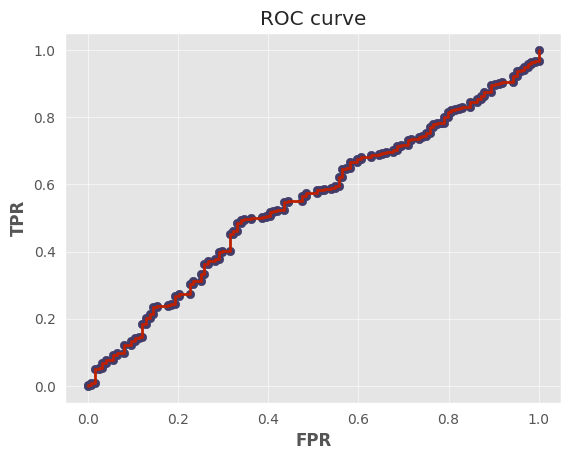

In [ ]:
#ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.scatter(fpr, tpr, color='#413c69')
plt.plot(fpr, tpr, color='#bd2000')
plt.title('ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR')

In [ ]:
# Align X_test columns with X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Calculate permutation importance with R-squared as the metric
importance_series_reg = manual_permutation_importance(reg, X_test, y_test, metric=r2_score)

print("Feature importances (regression):")
print(importance_series_reg)


NameError: name 'reg' is not defined